In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import(
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


In [3]:
from sklearn.decomposition import PCA

# Settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)


In [4]:
df = pd.read_csv('Data_for_UCI_named.csv')

print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Columns : {list(df.columns)}')

df.head()   # shows first 5 rows

Rows    : 10,000
Columns : 14
Columns : ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4', 'stab', 'stabf']


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [5]:
# --- Data types and null counts ---
print("=== df.info() ===")
df.info()

df.info()
print(df.dtypes.value_counts())

# --- Missing values ---
print("\n=== Missing values ===")
print(df.isnull().sum())

# --- Duplicate rows ---
print(f"\nDuplicate rows: {df.duplicated().sum()}")

=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64

In [6]:
df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
tau1,10000.0,5.2500,2.7425,0.5008,2.8749,5.2500,7.6247,9.9995
tau2,10000.0,5.2500,2.7425,0.5001,2.8751,5.2500,7.6249,9.9998
tau3,10000.0,5.2500,2.7425,0.5008,2.8755,5.2500,7.6249,9.9995
tau4,10000.0,5.2500,2.7426,0.5005,2.8750,5.2497,7.6248,9.9994
p1,10000.0,3.7500,0.7522,1.5826,3.2183,3.7510,4.2824,5.8644
p2,10000.0,-1.2500,0.4330,-1.9999,-1.6249,-1.2500,-0.8750,-0.5001
p3,10000.0,-1.2500,0.4330,-1.9999,-1.6250,-1.2500,-0.8750,-0.5001
p4,10000.0,-1.2500,0.4330,-1.9999,-1.6250,-1.2500,-0.8751,-0.5000
g1,10000.0,0.5250,0.2743,0.0500,0.2875,0.5250,0.7624,0.9999
g2,10000.0,0.5250,0.2743,0.0501,0.2876,0.5250,0.7625,0.9999


stabf
unstable    6380
stable      3620
Name: count, dtype: int64
stabf
unstable    63.8
stable      36.2
Name: proportion, dtype: float64


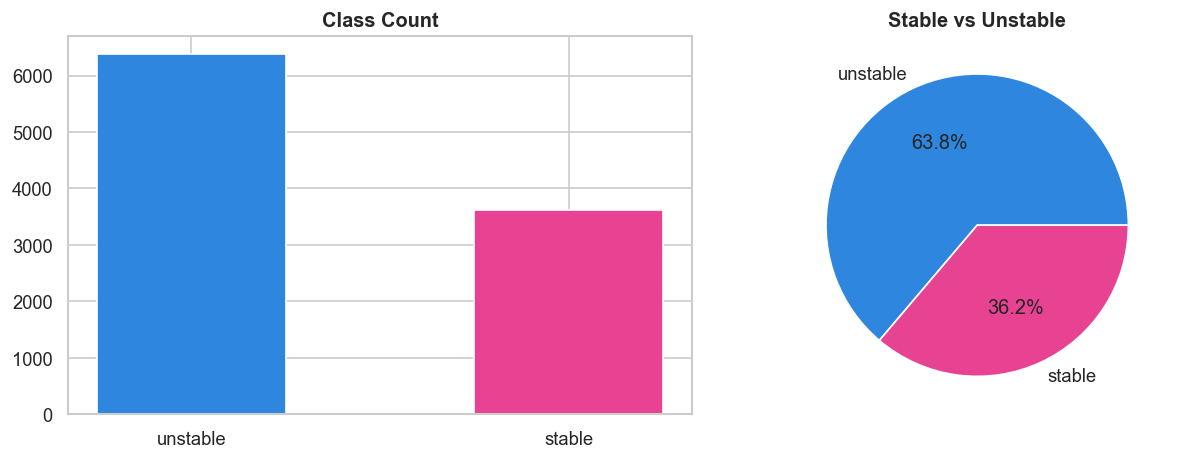

In [7]:
counts = df['stabf'].value_counts()
print(counts)
print(df['stabf'].value_counts(normalize=True)*100)

fig, axes = plt.subplots(1, 2, figsize=(11,4))
COLORS = ['#2E86DE','#E84393']
axes[0].bar(counts.index, counts.values, color=COLORS,
            edgecolor='white', width=0.5)
axes[0].set_title('Class Count', fontweight='bold')
axes[1].pie(counts.values, labels=counts.index,
            colors=COLORS, autopct='%1.1f%%')
axes[1].set_title('Stable vs Unstable', fontweight='bold')
plt.tight_layout(); plt.show()

In [8]:
print(df.isnull().sum())


tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64


In [9]:
dupes = df.duplicated().sum()
print(f'Duplicates: {dupes}')
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)

Duplicates: 0


In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'stab']

for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f'{col:12s}: {n_out} outliers')

tau1        : 0 outliers
tau2        : 0 outliers
tau3        : 0 outliers
tau4        : 0 outliers
p1          : 1 outliers
p2          : 0 outliers
p3          : 0 outliers
p4          : 0 outliers
g1          : 0 outliers
g2          : 0 outliers
g3          : 0 outliers
g4          : 0 outliers


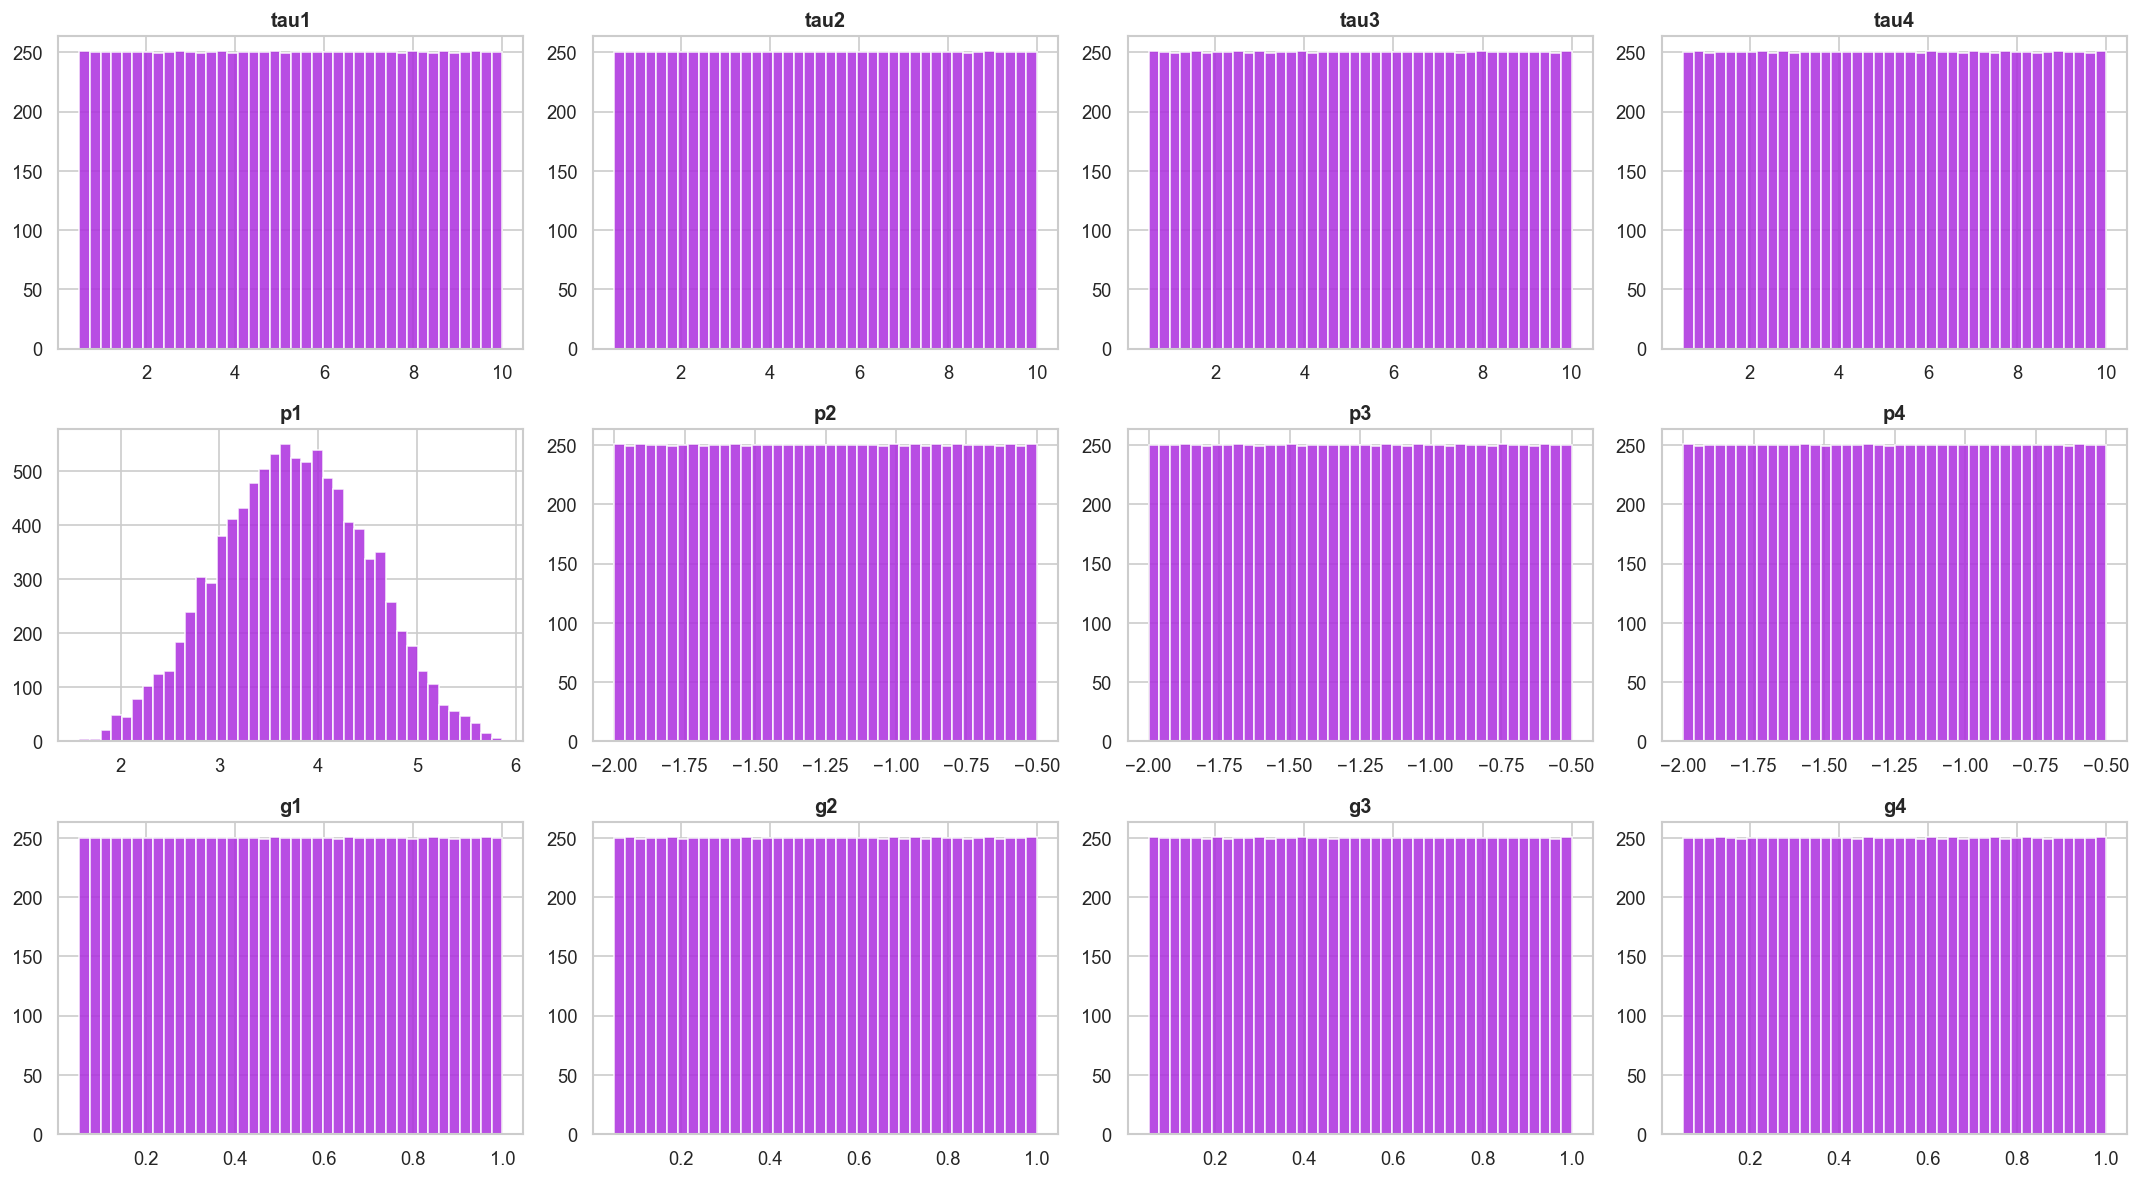

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color="#AC2EDE",
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold')
plt.tight_layout(); plt.show()

In [12]:
le = LabelEncoder()
df['target'] = le.fit_transform(df['stabf'])
# stable=0, unstable=1
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'stable': np.int64(0), 'unstable': np.int64(1)}


In [13]:
# Reaction-time aggregates
df['tau_mean']  = df[['tau1','tau2','tau3','tau4']].mean(axis=1)
df['tau_std']   = df[['tau1','tau2','tau3','tau4']].std(axis=1)
df['tau_range'] = df[['tau1','tau2','tau3','tau4']].max(axis=1) - \
                  df[['tau1','tau2','tau3','tau4']].min(axis=1)
# Power aggregates
df['p_total']   = df[['p1','p2','p3','p4']].sum(axis=1)
df['p_range']   = df[['p1','p2','p3','p4']].max(axis=1) - \
                  df[['p1','p2','p3','p4']].min(axis=1)
# Elasticity aggregates
df['g_mean']    = df[['g1','g2','g3','g4']].mean(axis=1)
df['g_std']     = df[['g1','g2','g3','g4']].std(axis=1)
print('✅ 7 new features created')

✅ 7 new features created


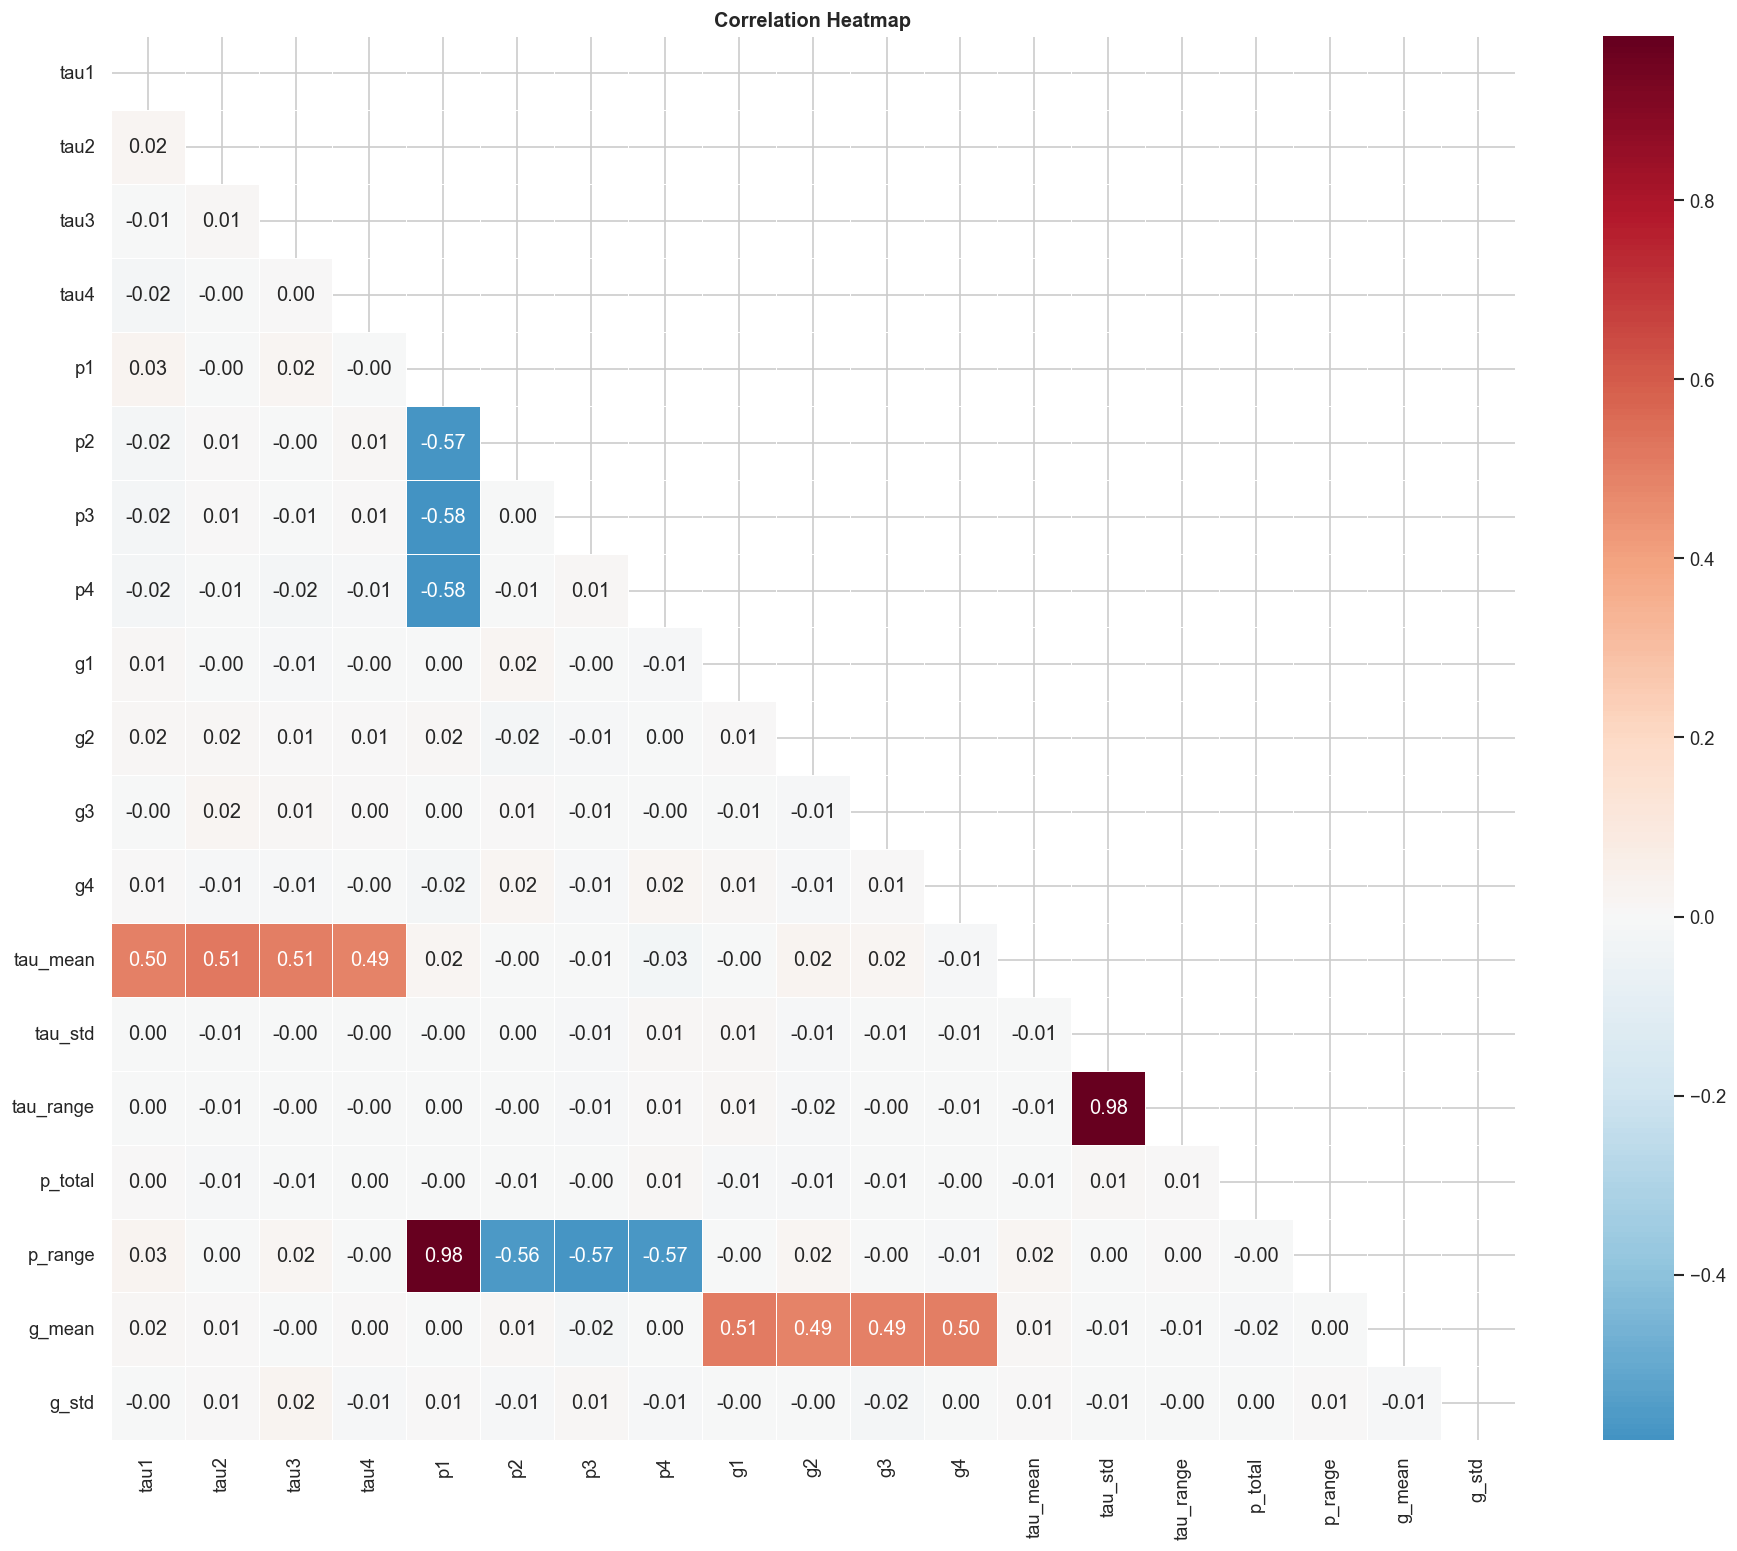

In [14]:
all_features = numeric_cols + ['tau_mean','tau_std','tau_range',
                              'p_total','p_range','g_mean','g_std']
corr = df[all_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(16,13))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.4,
            square=True)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
new_feats   = ['tau_mean','tau_std','tau_range',
               'p_total','p_range','g_mean','g_std']
FEATURE_COLS = numeric_cols + new_feats   # 19 features

X = df[FEATURE_COLS]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)     # NO fit on test!

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

Train: 8,000  |  Test: 2,000


In [16]:
models = {
  'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
  'Decision Tree'       : DecisionTreeClassifier(random_state=42),
  'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
  'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
  'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}
needs_scaling = {'Logistic Regression','K-Nearest Neighbors'}

In [18]:

from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    X_cv = X_train_sc if name in needs_scaling else X_train
    scores = cross_val_score(model, X_cv, y_train,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:28s}  {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression           0.8630 ± 0.0056
Decision Tree                 0.8386 ± 0.0062
K-Nearest Neighbors           0.8680 ± 0.0081
Random Forest                 0.9128 ± 0.0025
Gradient Boosting             0.9143 ± 0.0040


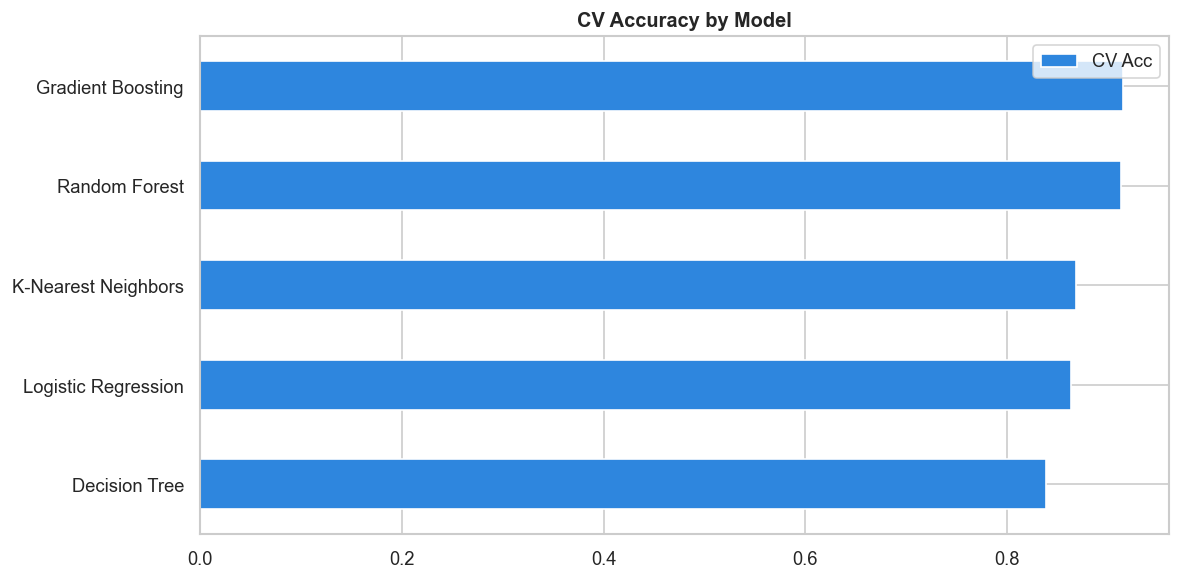

In [19]:
trained = {}
for name, model in models.items():
    X_tr = X_train_sc if name in needs_scaling else X_train
    model.fit(X_tr, y_train)
    trained[name] = model

# Bar chart
cv_df = pd.DataFrame({k: v.mean() for k,v in cv_results.items()},
                      index=['CV Acc']).T.sort_values('CV Acc')
cv_df.plot(kind='barh', figsize=(10,5), color='#2E86DE')
plt.title('CV Accuracy by Model', fontweight='bold')
plt.tight_layout(); plt.show()

In [22]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

records = []
preds_dict, proba_dict = {}, {}

for name, model in trained.items():
    X_te    = X_test_sc if name in needs_scaling else X_test
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    preds_dict[name] = y_pred
    proba_dict[name] = y_proba

    records.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba), 4)
    })

results_df = pd.DataFrame(records).set_index('Model') \
               .sort_values('F1 Score', ascending=False)

results_df.style.highlight_max(color='#d4f5e2').format('{:.4f}')  # ← fixed

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Gradient Boosting,0.9270,0.9373,0.9491,0.9431,0.9820
Random Forest,0.9235,0.9363,0.9444,0.9403,0.9799
Logistic Regression,0.8760,0.9028,0.9028,0.9028,0.9516
K-Nearest Neighbors,0.8695,0.8734,0.9303,0.9009,0.9404
Decision Tree,0.8325,0.8667,0.8715,0.8691,0.8176


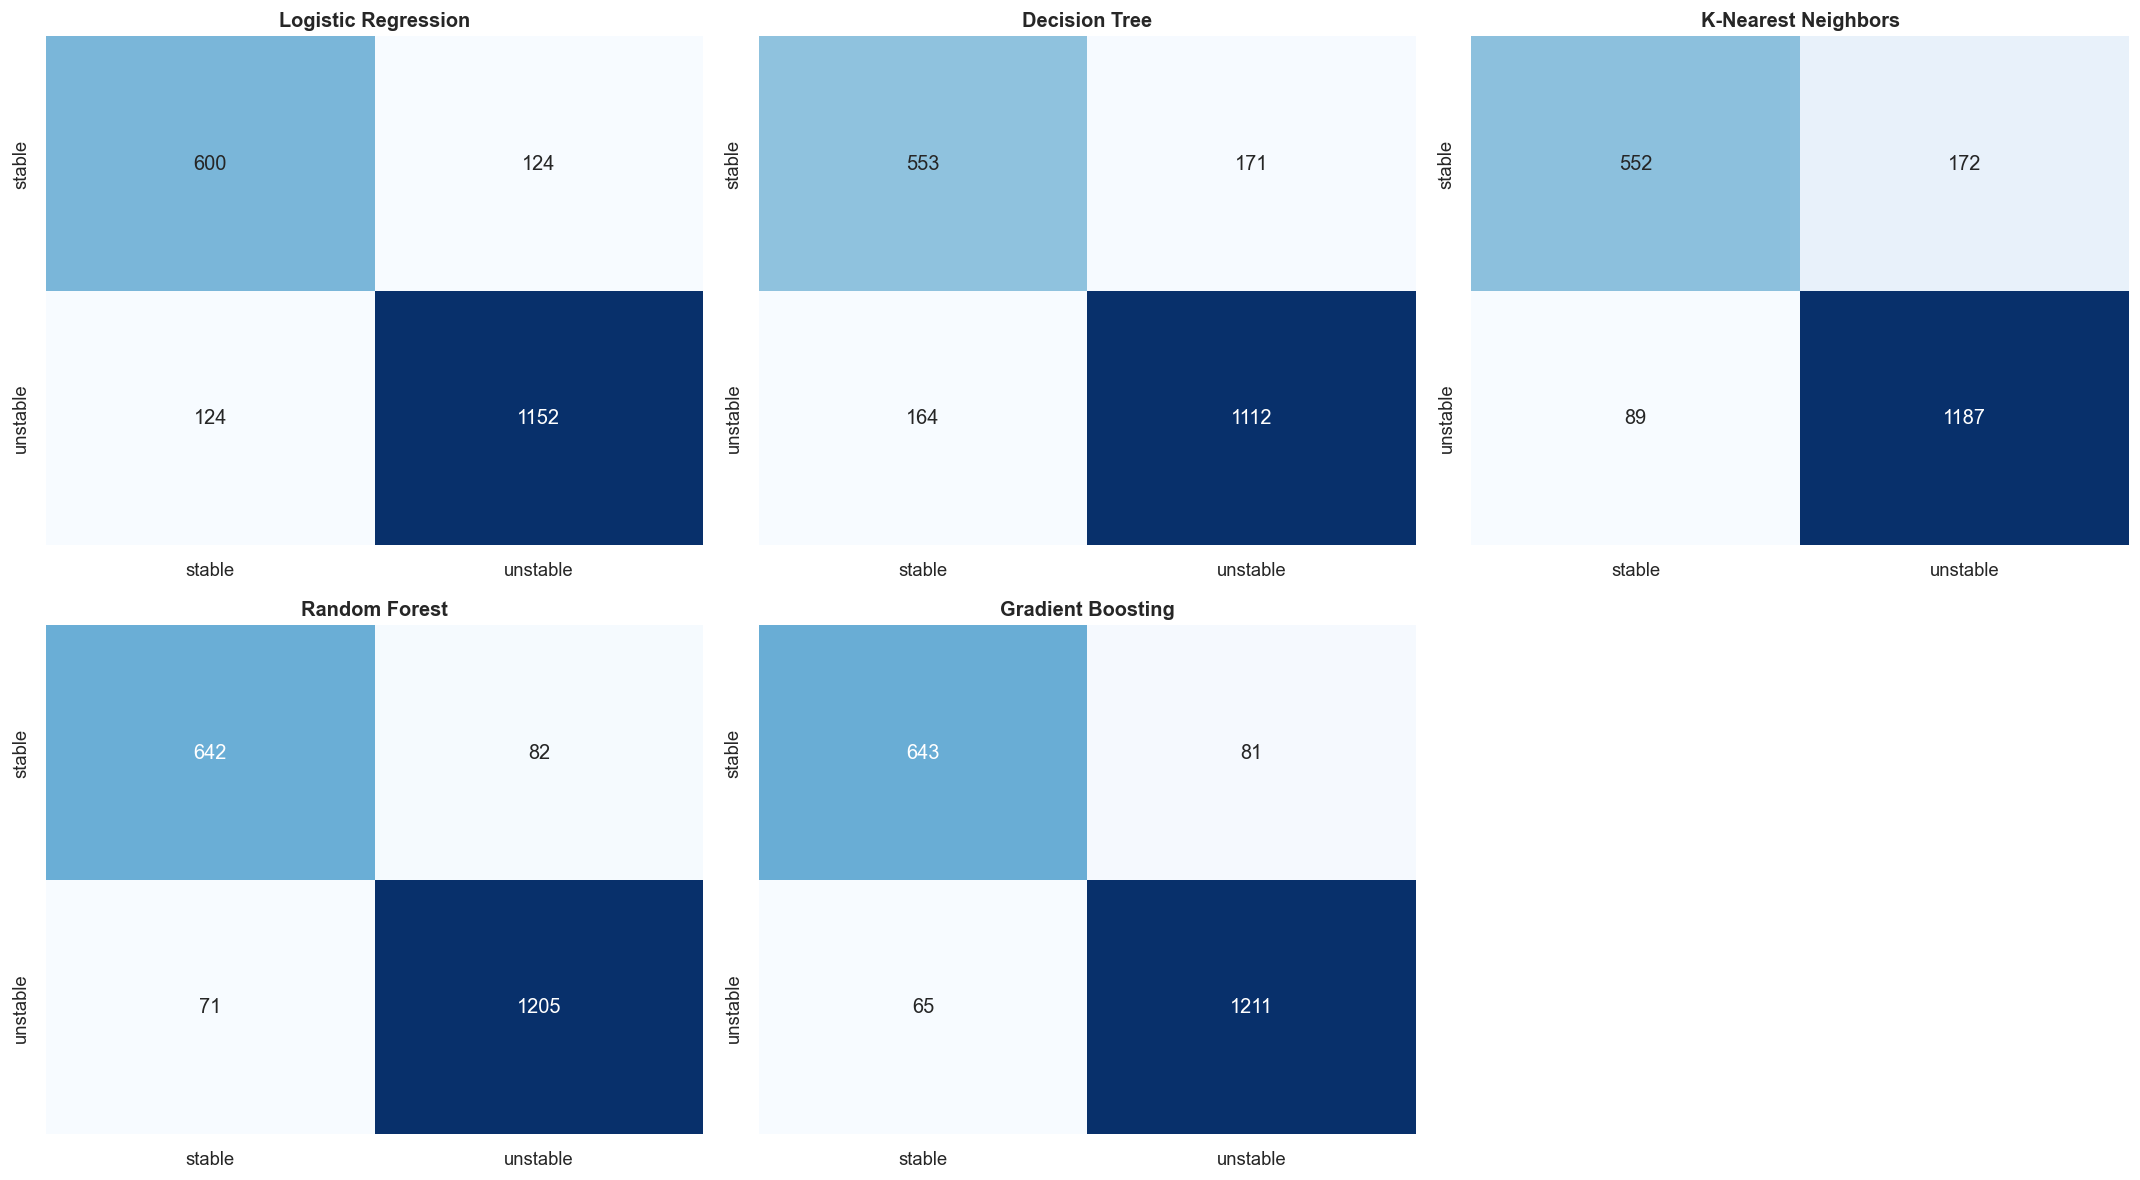

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()
for i, (name, y_pred) in enumerate(preds_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar=False,
                xticklabels=['stable','unstable'],
                yticklabels=['stable','unstable'], ax=axes[i])
    axes[i].set_title(name, fontweight='bold')
axes[-1].set_visible(False)
plt.tight_layout(); plt.show()

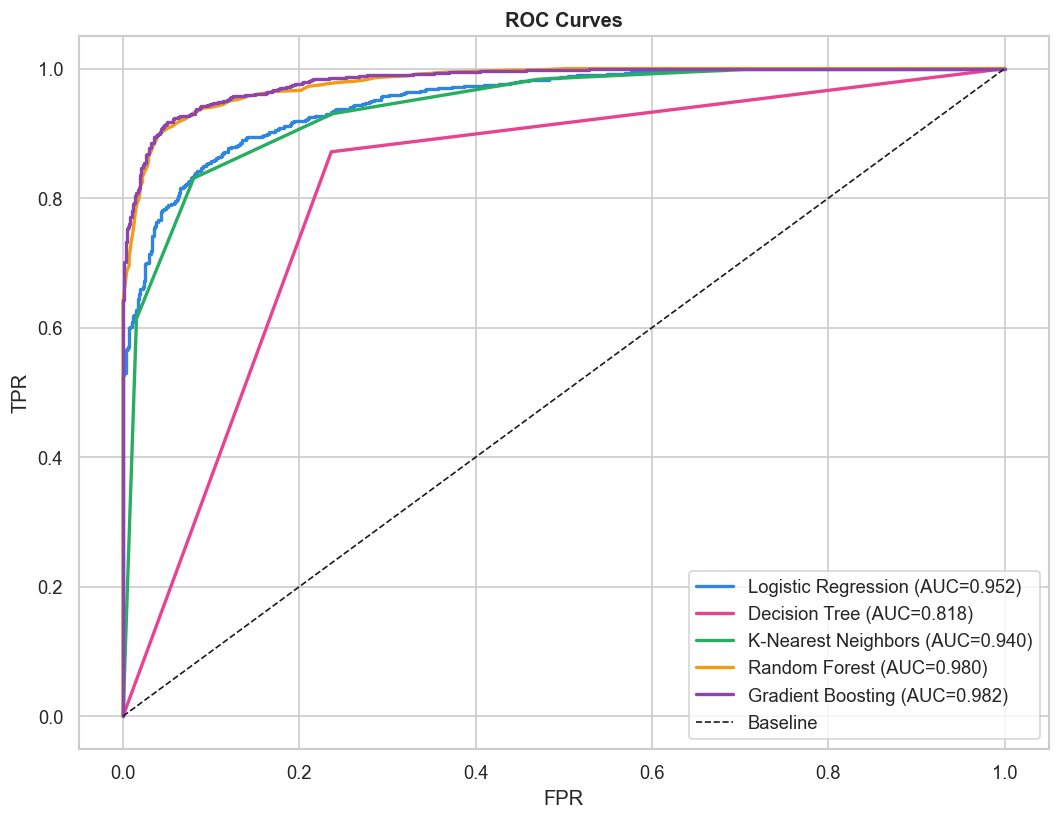

In [24]:
colors = ['#2E86DE','#E84393','#27AE60','#F39C12','#8E44AD']
plt.figure(figsize=(9,7))
for (name, proba), color in zip(proba_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',lw=1,label='Baseline')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2']
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)
print('Best params :', grid.best_params_)
print('Best CV F1  :', round(grid.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1  : 0.9326


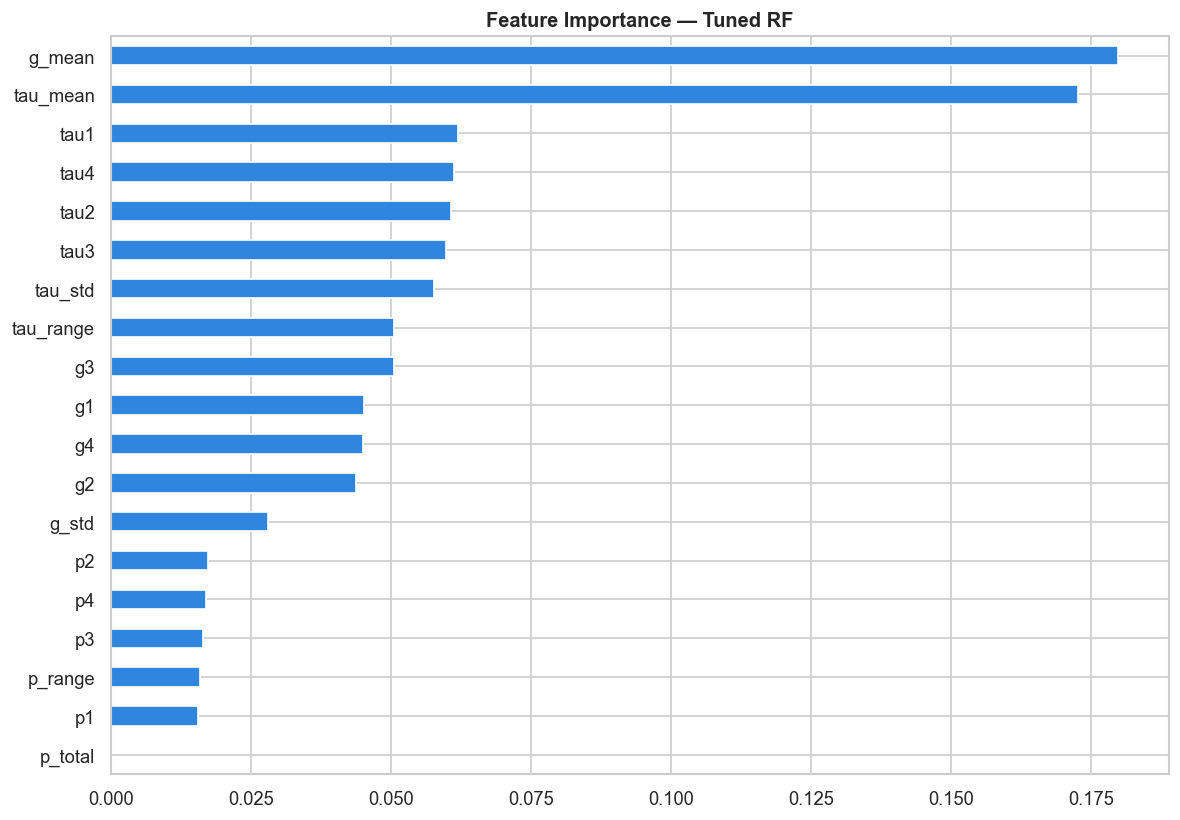

Top 5: g_mean      0.179903
tau_mean    0.172731
tau1        0.061946
tau4        0.061302
tau2        0.060691
dtype: float64


In [27]:
best_rf  = grid.best_estimator_
feat_imp = pd.Series(best_rf.feature_importances_,
                     index=FEATURE_COLS).sort_values()

feat_imp.plot(kind='barh', figsize=(10,7), color='#2E86DE')
plt.title('Feature Importance — Tuned RF', fontweight='bold')
plt.tight_layout(); plt.show()
print('Top 5:', feat_imp.sort_values(ascending=False).head())

In [29]:
import joblib

joblib.dump(best_rf, 'best_model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('✅ Model saved → best_model_rf.pkl')

✅ Model saved → best_model_rf.pkl


In [30]:
loaded_model = joblib.load('best_model_rf.pkl')

# New sample — replace with real readings
sample = pd.DataFrame([{
    'tau1':2.95,'tau2':3.08,'tau3':8.38,'tau4':9.78,
    'p1':3.76,'p2':-0.78,'p3':-1.25,'p4':-1.72,
    'g1':0.65,'g2':0.86,'g3':0.89,'g4':0.96
}])
sample['tau_mean']  = sample[['tau1','tau2','tau3','tau4']].mean(axis=1)
sample['tau_std']   = sample[['tau1','tau2','tau3','tau4']].std(axis=1)
sample['tau_range'] = sample[['tau1','tau2','tau3','tau4']].max(axis=1) - sample[['tau1','tau2','tau3','tau4']].min(axis=1)
sample['p_total']   = sample[['p1','p2','p3','p4']].sum(axis=1)
sample['p_range']   = sample[['p1','p2','p3','p4']].max(axis=1) - sample[['p1','p2','p3','p4']].min(axis=1)
sample['g_mean']    = sample[['g1','g2','g3','g4']].mean(axis=1)
sample['g_std']     = sample[['g1','g2','g3','g4']].std(axis=1)

pred  = loaded_model.predict(sample[FEATURE_COLS])[0]
proba = loaded_model.predict_proba(sample[FEATURE_COLS])[0]
label = 'UNSTABLE ⚠️' if pred==1 else 'STABLE ✅'
print(f'Prediction : {label}')
print(f'Probability: stable={proba[0]:.3f} | unstable={proba[1]:.3f}')


Prediction : UNSTABLE ⚠️
Probability: stable=0.040 | unstable=0.960


In [31]:
y_best = best_rf.predict(X_test)
y_bp   = best_rf.predict_proba(X_test)[:,1]
print('═'*52)
print('  CAPSTONE — FINAL RESULTS')
print('═'*52)
print(f'  Accuracy  : {accuracy_score(y_test,y_best):.4f}')
print(f'  F1 Score  : {f1_score(y_test,y_best):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test,y_bp):.4f}')
print('  Best Model: Tuned Random Forest')
print('═'*52)

════════════════════════════════════════════════════
  CAPSTONE — FINAL RESULTS
════════════════════════════════════════════════════
  Accuracy  : 0.9265
  F1 Score  : 0.9428
  ROC-AUC   : 0.9807
  Best Model: Tuned Random Forest
════════════════════════════════════════════════════
